<a href="https://colab.research.google.com/github/Keshavanand20/Machine_Learning/blob/main/Predicting_the_House_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
#from sklearn.datasets import load_boston

In [ ]:
# getting the data from the URL
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# Read the raw data (space-separated, skip metadata)
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)

# data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]]) # "raw_df.values" Convert DataFrame to NumPy array
# raw_data[::2] are the even rows
# raw_data[1::2, :2] are the odd rows and ",:2" defines the first 2 columns of those rows (0,1)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :3]])

target = raw_df.values[1::2, 2] #Combine features into one array (13 features total)
# this column contains the Median value of owner-occupied homes in $1000's and that is the data we will be looking at

in line 2 of the above code:
* In Python string literals, a backslash is used to escape characters (e.g., \n for a newline, \t for a tab). When Python encounters \s in a regular string, it doesn't have a specific meaning in the standard string literal context and thus raises a warning
* Use a raw string literal (Recommended for regex): Prefix your string with an r or R. Raw strings treat backslashes as literal characters, so Python's string parser won't attempt to interpret the escape sequences. The backslashes are passed directly to the regular expression engine, which understands \s.
* Change from: pattern = "\s+"
* Change to: pattern = r"\s+"

In [ ]:
raw_df

,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8
...,...,...,...,...,...,...,...,...,...,...,...
1007,396.90000,5.64,23.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1008,0.10959,0.00,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0
1009,393.45000,6.48,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1010,0.04741,0.00,11.93,0.0,0.573,6.030,80.8,2.5050,1.0,273.0,21.0


In [ ]:
data

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 3.9690e+02, 4.9800e+00,
        2.4000e+01],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 3.9690e+02, 9.1400e+00,
        2.1600e+01],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 3.9283e+02, 4.0300e+00,
        3.4700e+01],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 3.9690e+02, 5.6400e+00,
        2.3900e+01],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 3.9345e+02, 6.4800e+00,
        2.2000e+01],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 3.9690e+02, 7.8800e+00,
        1.1900e+01]])

Problem Statement
* you have been given a dataset that descrobes the houses in boston. Now, based on the given features you have to predict the house prices.

In [ ]:
# these are the column names from the data set itself
features = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM","AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT","PRICE"]

df = pd.DataFrame(data, columns=features)

In [ ]:
# here we have separated the meadian value column
target = pd.DataFrame(target, columns=["PRICE"])

# EDA - Exploratory Data Analysis

In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


# Columns Information
* CRIM     per capita crime rate by town
* ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
* INDUS    proportion of non-retail business acres per town
* CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
* NOX      nitric oxides concentration (parts per 10 million)
* RM       average number of rooms per dwelling
* AGE      proportion of owner-occupied units built prior to 1940
* DIS      weighted distances to five Boston employment centres
* RAD      index of accessibility to radial highways
* TAX      full-value property-tax rate per $10,000

* PTRATIO  pupil-teacher ratio by town
 B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
* LSTAT    % lower status of the population
* PRICE     Median value of owner-occupied homes in $1000's

In [ ]:
target.head()

,PRICE
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2


In [ ]:
df.shape

(506, 14)

In [ ]:
df.dtypes

,0
CRIM,float64
ZN,float64
INDUS,float64
CHAS,float64
NOX,float64
RM,float64
AGE,float64
DIS,float64
RAD,float64
TAX,float64


In [ ]:
# this tells the unique values in a single column
df["ZN"].unique()

array([ 18. ,   0. ,  12.5,  75. ,  21. ,  90. ,  85. , 100. ,  25. ,
        17.5,  80. ,  28. ,  45. ,  60. ,  95. ,  82.5,  30. ,  22. ,
        20. ,  40. ,  55. ,  52.5,  70. ,  34. ,  33. ,  35. ])

In [ ]:
# this func tells the total number of unique values in every column
df.nunique()

,0
CRIM,504
ZN,26
INDUS,76
CHAS,2
NOX,81
RM,446
AGE,356
DIS,412
RAD,9
TAX,66


In [ ]:
# total number of missing values in each column
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
# to check the correaltion between features
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


<Axes: >

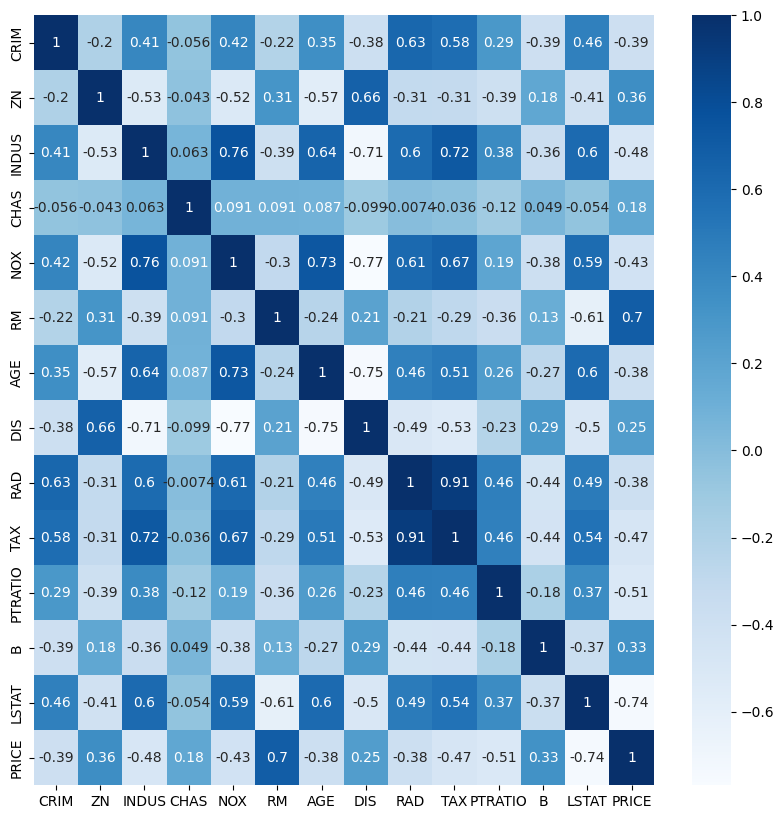

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, cmap="Blues")
# "annot" being True shows the values in each box


/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


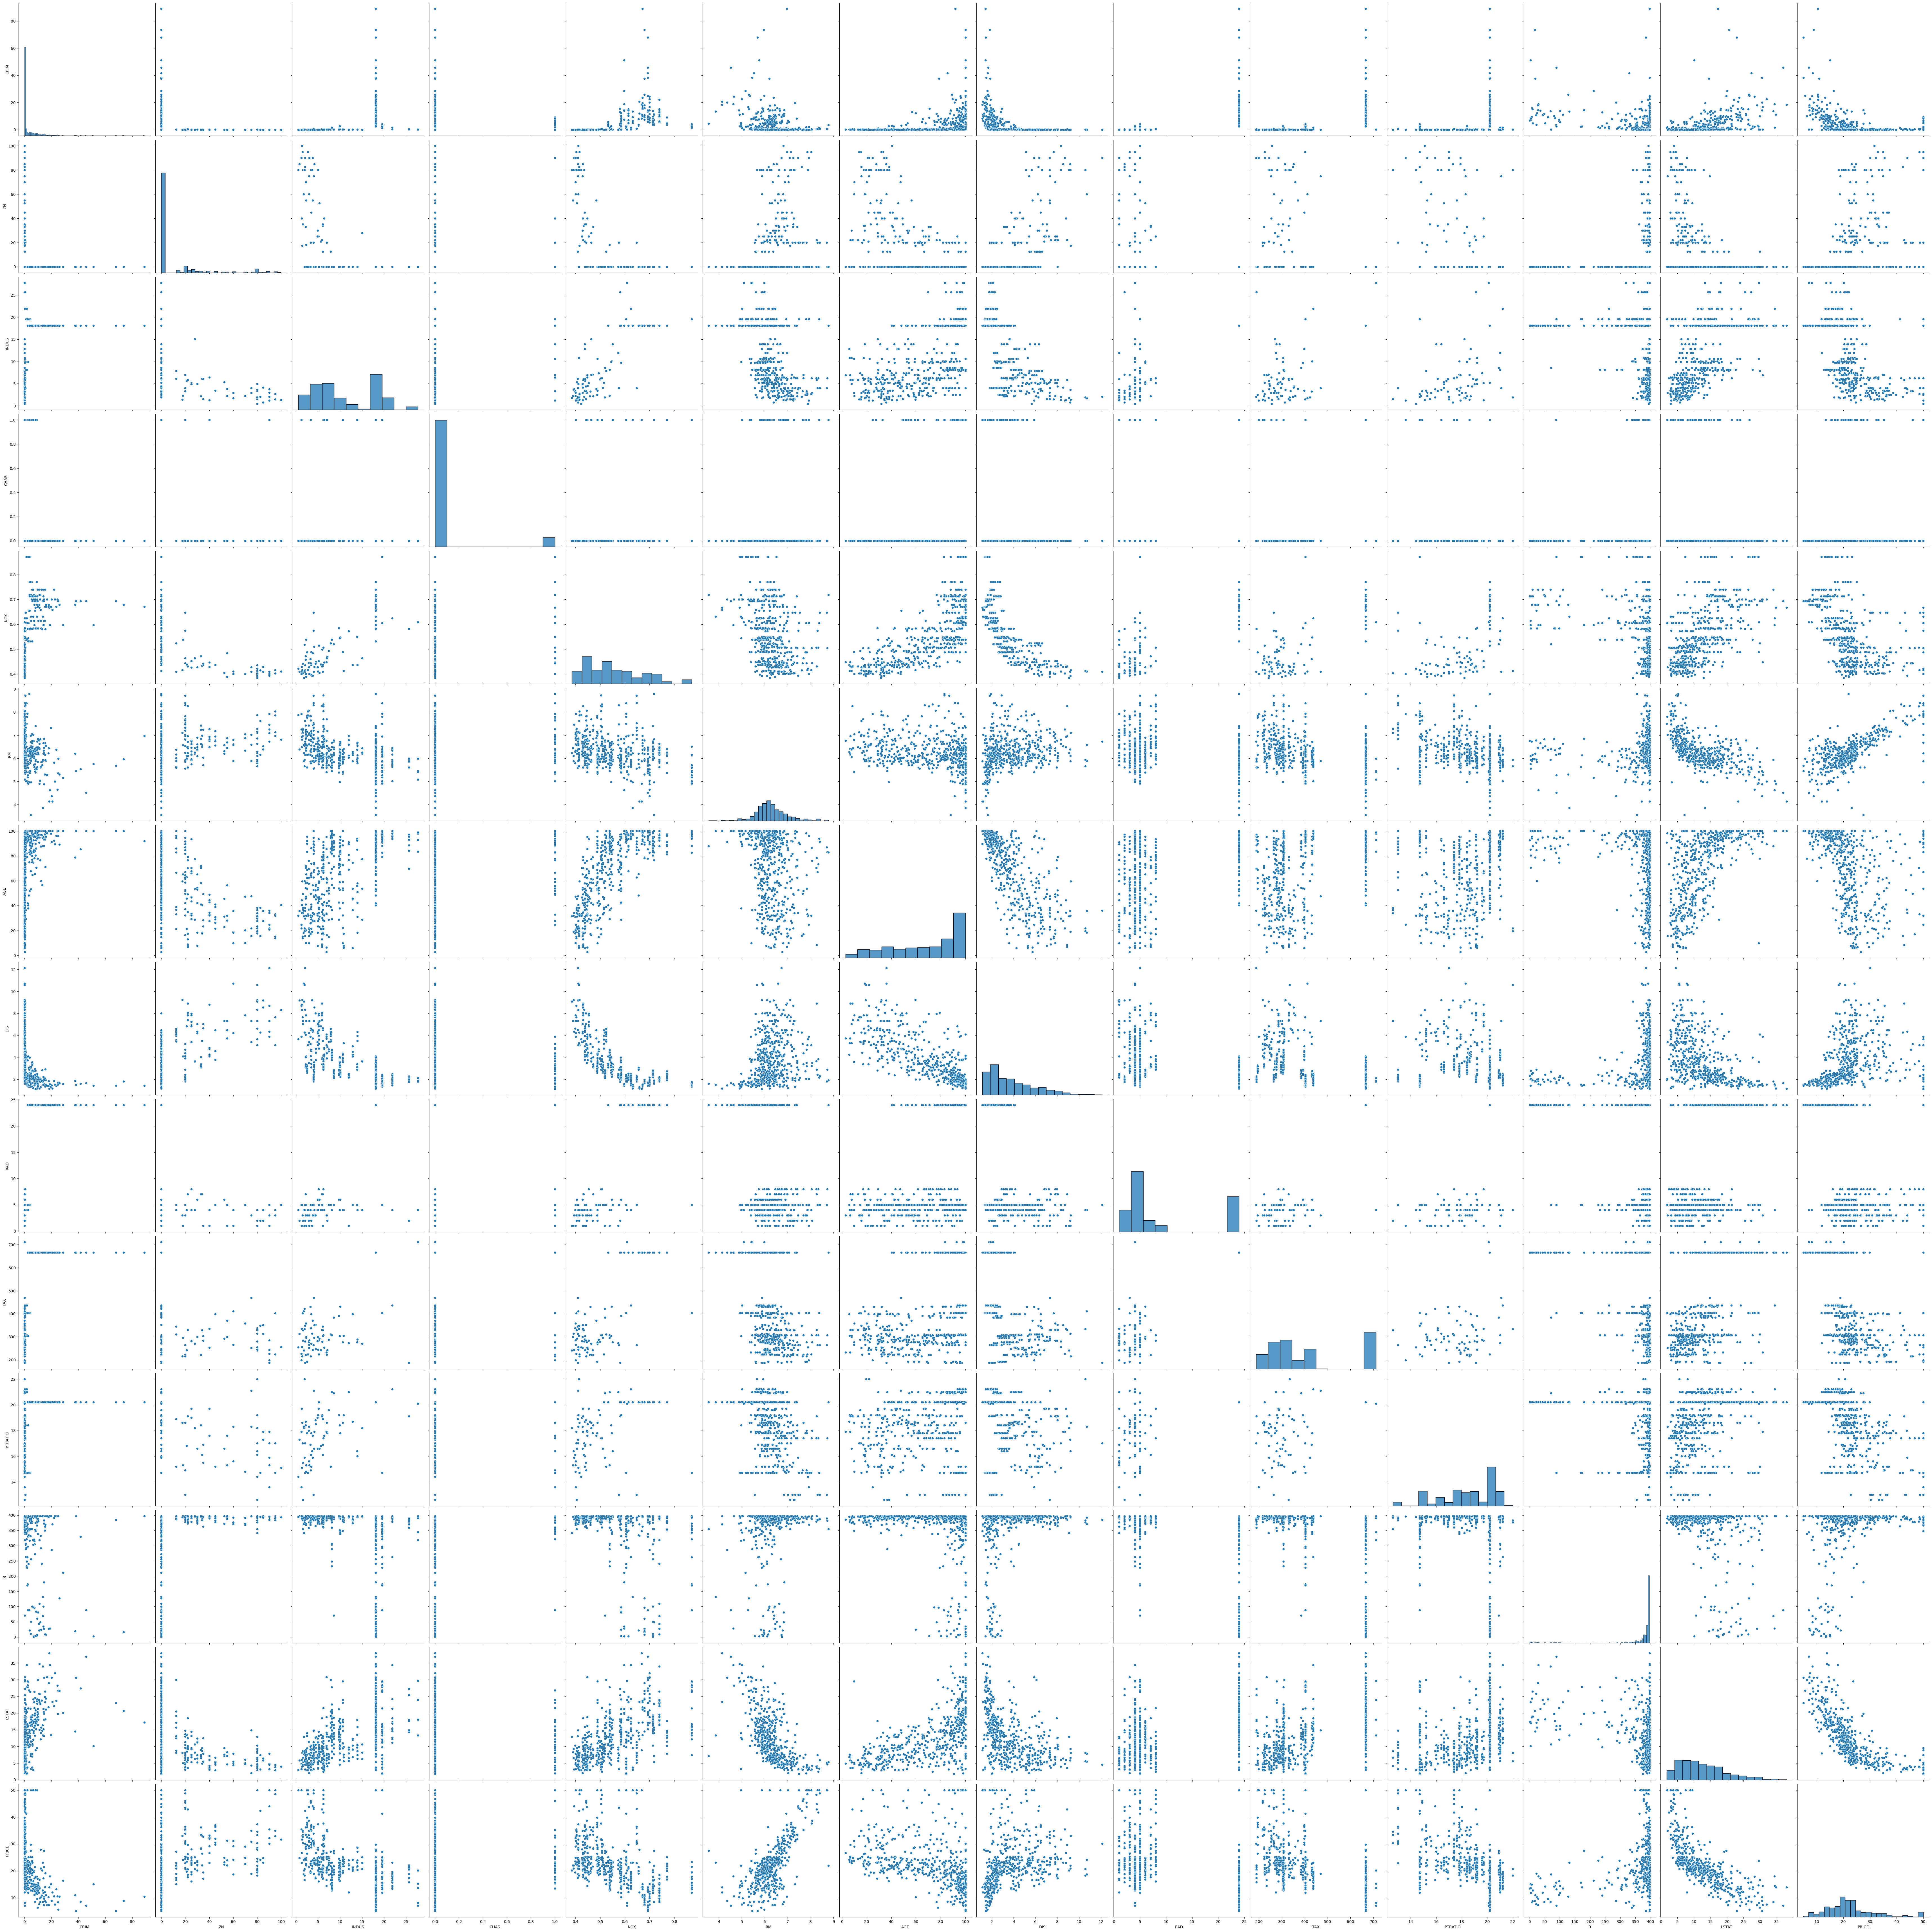

In [ ]:
sns.pairplot(df, size=5)

<Figure size 5000x5000 with 0 Axes>

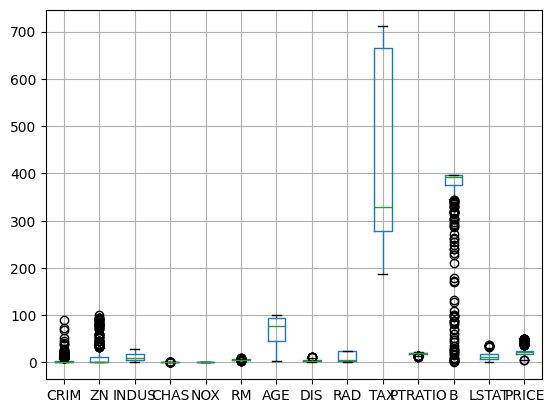

<Figure size 5000x5000 with 0 Axes>

In [ ]:
#plot a boxplot
df.boxplot()
plt.figure(figsize=(50,50))

In [ ]:
# Minimum price
df["PRICE"].min()

5.0

In [ ]:
df.PRICE.max()

50.0

In [ ]:
df.PRICE.std()

9.19710408737982

# Export the Dataset

In [ ]:
df.to_csv("boston_dataset.csv")

# Machine Learning

In [ ]:
df.head()
df.shape

(506, 14)

In [ ]:
# we want to separate the features and Traget in x and y respectively
# the function "iloc" is used for the slicning of the data frames
x = df.iloc[::,:13:]
y = df.iloc[::,13::]

In [ ]:
# converting the seperated data into 2d arrays
x = np.array(x)
y = np.array(y)

Splitting the data

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size =0.2,random_state = 42)

In [ ]:
print(len(x_train))
print(len(x_test))
print(len(y_train))
print(len(y_test))

404
102
404
102


Model Selection

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

Fitting/Train the model

In [ ]:
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
# Intercept value (c)
model.intercept_

array([30.24675099])

In [ ]:
model.coef_

array([[-1.13055924e-01,  3.01104641e-02,  4.03807204e-02,
         2.78443820e+00, -1.72026334e+01,  4.43883520e+00,
        -6.29636221e-03, -1.44786537e+00,  2.62429736e-01,
        -1.06467863e-02, -9.15456240e-01,  1.23513347e-02,
        -5.08571424e-01]])

Let's make prediction

In [ ]:
print(y_test)

[[23.6]
 [32.4]
 [13.6]
 [22.8]
 [16.1]
 [20. ]
 [17.8]
 [14. ]
 [19.6]
 [16.8]
 [21.5]
 [18.9]
 [ 7. ]
 [21.2]
 [18.5]
 [29.8]
 [18.8]
 [10.2]
 [50. ]
 [14.1]
 [25.2]
 [29.1]
 [12.7]
 [22.4]
 [14.2]
 [13.8]
 [20.3]
 [14.9]
 [21.7]
 [18.3]
 [23.1]
 [23.8]
 [15. ]
 [20.8]
 [19.1]
 [19.4]
 [34.7]
 [19.5]
 [24.4]
 [23.4]
 [19.7]
 [28.2]
 [50. ]
 [17.4]
 [22.6]
 [15.1]
 [13.1]
 [24.2]
 [19.9]
 [24. ]
 [18.9]
 [35.4]
 [15.2]
 [26.5]
 [43.5]
 [21.2]
 [18.4]
 [28.5]
 [23.9]
 [18.5]
 [25. ]
 [35.4]
 [31.5]
 [20.2]
 [24.1]
 [20. ]
 [13.1]
 [24.8]
 [30.8]
 [12.7]
 [20. ]
 [23.7]
 [10.8]
 [20.6]
 [20.8]
 [ 5. ]
 [20.1]
 [48.5]
 [10.9]
 [ 7. ]
 [20.9]
 [17.2]
 [20.9]
 [ 9.7]
 [19.4]
 [29. ]
 [16.4]
 [25. ]
 [25. ]
 [17.1]
 [23.2]
 [10.4]
 [19.6]
 [17.2]
 [27.5]
 [23. ]
 [50. ]
 [17.9]
 [ 9.6]
 [17.2]
 [22.5]
 [21.4]]


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
y_pred

array([[28.99672362],
       [36.02556534],
       [14.81694405],
       [25.03197915],
       [18.76987992],
       [23.25442929],
       [17.66253818],
       [14.34119   ],
       [23.01320703],
       [20.63245597],
       [24.90850512],
       [18.63883645],
       [-6.08842184],
       [21.75834668],
       [19.23922576],
       [26.19319733],
       [20.64773313],
       [ 5.79472718],
       [40.50033966],
       [17.61289074],
       [27.24909479],
       [30.06625441],
       [11.34179277],
       [24.16077616],
       [17.86058499],
       [15.83609765],
       [22.78148106],
       [14.57704449],
       [22.43626052],
       [19.19631835],
       [22.43383455],
       [25.21979081],
       [25.93909562],
       [17.70162434],
       [16.76911711],
       [16.95125411],
       [31.23340153],
       [20.13246729],
       [23.76579011],
       [24.6322925 ],
       [13.94204955],
       [32.25576301],
       [42.67251161],
       [17.32745046],
       [27.27618614],
       [16

i was trying to Visualize the difference between the predicted values and the actual values using a plot and following are things that i found:
* since this specific model is a multi linear regression model we cannot plot the data points on a scatter plot
* we instead use a pairplot to visualize it


#Testing the model performance

In [ ]:
model.score(x_test,y_test)

0.6687594935356325

In [ ]:
r2_score(y_test,y_pred)

0.6687594935356325

In [ ]:
mean_squared_error(y_test,y_pred)


24.291119474973485

In [ ]:
mean_absolute_error(y_test,y_pred)

3.189091965887834

In [ ]:
# root mean squared error
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(4.928602182665333)

Text(0.5, 1.0, 'Actual v/s Predicted price')

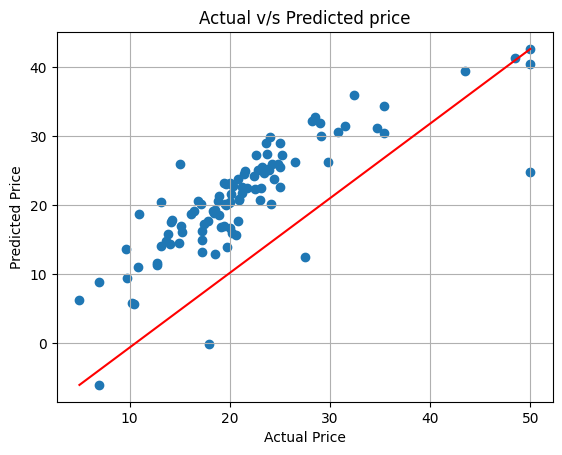

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.grid()
plt.plot([min(y_test),max(y_test)],[min(y_pred),max(y_pred)], color = "red")
plt.title("Actual v/s Predicted price")